# Snake RL — Training Run Analysis

Analyzes training runs logged to MLflow and documents reconstructed notes from runs where data was not captured.

**Runs summary:**
| Run | Grid (playable) | food | collision | ent_coef | toward | Outcome |
|-----|----------------|------|-----------|----------|--------|--------|
| 1 | 24×24 (total) | 64 | -8 | 0.05 | 0.10 | Shaping local optimum — wandered, no food |
| 2 | 14×14 (16×16 total, border bug) | 64 | -8 | 0.05 | 0.01 | Same local optimum, entropy collapsed |
| 3 | 16×16 (18×18 total) | 16 | -2 | 0.10 | 0.01 | Entropy stuck at max — policy stayed random |
| 4 | 16×16 | 16 | -2 | 0.02 | 0.0 | Pending |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import mlflow
from mlflow.tracking import MlflowClient

sns.set_theme(style='darkgrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

DB_PATH = (Path('..') / 'mlruns' / 'mlflow.db').resolve()
TRACKING_URI = f'sqlite:///{DB_PATH}'
mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient(TRACKING_URI)
exp = client.get_experiment_by_name('snake-rl')
print(f'Tracking URI: {TRACKING_URI}')
print(f'Experiment ID: {exp.experiment_id}')

Tracking URI: sqlite:////home/jgalloway/workspace/snake_rl/mlruns/mlflow.db
Experiment ID: 1


## Reconstructed notes: Runs 1 & 2

MLflow data was not captured for Runs 1 and 2. The following is reconstructed from observations during training.

### Run 1 — 24×24 grid, toward=0.10 (pre-2026-03-22)

**Config:** `grid=24×24 (total)`, `food=64`, `collision=-8`, `ent_coef=0.05`, `toward=0.10`, `away=-0.05`, `max_steps=500`, `lr=0.0003`

| Checkpoint | ep_rew_mean | ep_len_mean | explained_variance | entropy_loss | Notes |
|-----------|------------|------------|-------------------|-------------|-------|
| ~500k | ~20 | ~200 | — | — | Healthy early progress |
| ~925k | ~30 | ~314 | 0.32 | — | Plateau confirmed; value_loss=19.8, approx_kl=0.023 |
| ~1.2–1.3M | ~30.7 | ~314 | — | — | Best checkpoint |
| ~2.1M | 11–17 | — | 0.12–0.33 | -0.97 | Regression; entropy collapsed; policy deterministic |

**Diagnosis:** `toward=0.10` over 500 steps ≈ 30–50 reward/episode from shaping alone, comparable to food=64 reward. Agent optimized shaping instead of eating food. Live preview showed yellow borders (timeout), not red (collision) — agent learned to survive by wandering. Entropy collapsed to -0.97 by 2.1M steps.

**Key insight:** When shaping reward is large enough to substitute for food reward, the agent never needs to eat.

---

### Run 2 — 16×16 grid (14×14 playable due to border bug), toward=0.01 (2026-03-22)

**Config:** `grid=16×16 total (14×14 playable)`, `food=64`, `collision=-8`, `ent_coef=0.05`, `toward=0.01`, `away=-0.02`, `max_steps=300`, `lr=0.0001`

| Checkpoint | ep_rew_mean | ep_len_mean | explained_variance | entropy_loss | Notes |
|-----------|------------|------------|-------------------|-------------|-------|
| 3.1M (stopped) | 10.4 | 138 | 0.517 | -0.873 | Plateau; entropy declining; zero food being eaten |

**Diagnosis:** With `food=64` and `ep_rew_mean=10.4`, all reward is shaping (138 steps × 0.01 ≈ 1 reward from toward signal — the rest is structure noise). The agent ate essentially zero food across 3.1M steps. Entropy was collapsing toward determinism. Live preview: single-cell snake (no growth) never near food. `value_loss=41.6` — high variance in value function due to food=64 scale. Also affected by border bug: config said 16×16 but playable space was only 14×14.

**Key insight:** `collision=-8` was expensive enough that the agent learned risk-aversion before discovering food. `food=64` caused high value-function variance.

## Load MLflow runs

In [2]:
def get_metric_df(run_id: str, metric: str) -> pd.DataFrame:
    """Return a DataFrame with columns [step, value] for a given metric."""
    history = client.get_metric_history(run_id, metric)
    if not history:
        return pd.DataFrame(columns=['step', metric])
    return pd.DataFrame({'step': [h.step for h in history], metric: [h.value for h in history]})


def get_run_summary(run) -> dict:
    """Extract a flat summary dict from an MLflow run."""
    import datetime
    p = run.data.params
    m = run.data.metrics
    return {
        'run_id': run.info.run_id[:8],
        'start': datetime.datetime.fromtimestamp(run.info.start_time / 1000).strftime('%Y-%m-%d %H:%M'),
        'status': run.info.status,
        'food': float(p.get('reward.food', 'nan')),
        'collision': float(p.get('reward.collision', 'nan')),
        'toward': float(p.get('reward.toward', 'nan')),
        'ent_coef': float(p.get('ppo.ent_coef', 'nan')),
        'lr': float(p.get('ppo.learning_rate', 'nan')),
        'grid': f"{p.get('env.grid_w')}×{p.get('env.grid_h')}",
        'max_steps': int(p.get('env.max_steps', 0)),
        'final_ep_rew': m.get('ep_rew_mean', float('nan')),
        'final_ep_len': m.get('ep_len_mean', float('nan')),
        'final_entropy': m.get('entropy', float('nan')),
        'final_value_loss': m.get('value_loss', float('nan')),
    }


all_runs = client.search_runs(exp.experiment_id, order_by=['start_time ASC'])
summaries = [get_run_summary(r) for r in all_runs]
summary_df = pd.DataFrame(summaries)
print(f'{len(all_runs)} run(s) found in MLflow')
summary_df

1 run(s) found in MLflow


,run_id,start,status,food,collision,toward,ent_coef,lr,grid,max_steps,final_ep_rew,final_ep_len,final_entropy,final_value_loss
0,d71a9426,2026-03-22 20:46,FINISHED,16.0,-2.0,0.01,0.1,0.0001,16×16,300,2.9148,98.52,-1.010905,1.905485


## Run 3 — Full metric curves

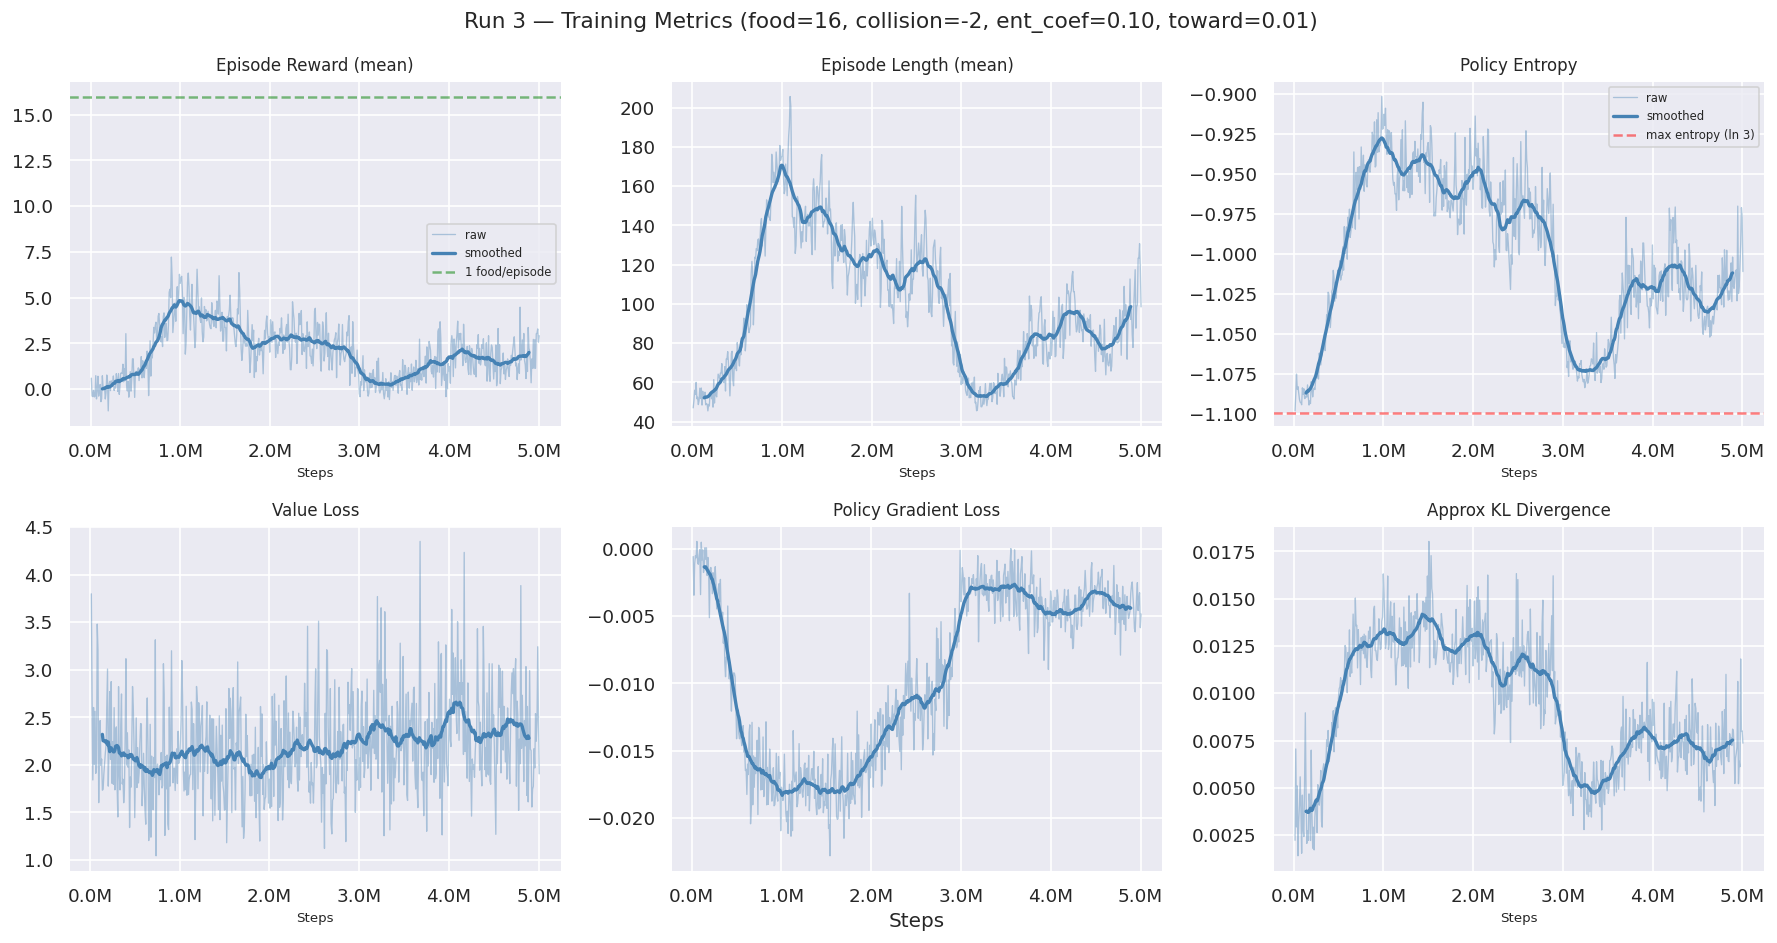

In [3]:
# Load Run 3 (the only MLflow run)
run3 = all_runs[0]
run3_id = run3.info.run_id

metrics_to_plot = ['ep_rew_mean', 'ep_len_mean', 'entropy', 'value_loss', 'policy_loss', 'approx_kl']
run3_data = {m: get_metric_df(run3_id, m) for m in metrics_to_plot}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Run 3 — Training Metrics (food=16, collision=-2, ent_coef=0.10, toward=0.01)', fontsize=13)

labels = {
    'ep_rew_mean':  ('Episode Reward (mean)', 'Expected ~16 per food eaten'),
    'ep_len_mean':  ('Episode Length (mean)', 'max_steps=300'),
    'entropy':      ('Policy Entropy', 'Max possible for 3 actions = ln(3) ≈ 1.099'),
    'value_loss':   ('Value Loss', 'Lower is better'),
    'policy_loss':  ('Policy Gradient Loss', ''),
    'approx_kl':    ('Approx KL Divergence', 'Clip range = 0.2'),
}

for ax, metric in zip(axes.flat, metrics_to_plot):
    df = run3_data[metric]
    if df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.plot(df['step'], df[metric], alpha=0.4, linewidth=0.8, color='steelblue', label='raw')
        # Smoothed
        if len(df) > 20:
            smoothed = df[metric].rolling(window=max(1, len(df)//20), center=True).mean()
            ax.plot(df['step'], smoothed, linewidth=2, color='steelblue', label='smoothed')
        ax.set_title(labels[metric][0], fontsize=10)
        if labels[metric][1]:
            ax.set_xlabel(labels[metric][1], fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        ax.set_xlabel('Steps')
        if metric == 'entropy':
            ax.axhline(-1.099, color='red', linestyle='--', alpha=0.5, label='max entropy (ln 3)')
            ax.legend(fontsize=7)
        elif metric == 'ep_rew_mean':
            ax.axhline(16, color='green', linestyle='--', alpha=0.5, label='1 food/episode')
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../notebooks/run3_metrics.png', bbox_inches='tight')
plt.show()

## Run 3 — Diagnosis

In [4]:
ent_df = run3_data['entropy']
rew_df = run3_data['ep_rew_mean']
len_df = run3_data['ep_len_mean']

max_entropy_3actions = np.log(3)  # ≈ 1.099 nats

print('=== Run 3 Diagnosis ===')
print()
if not ent_df.empty:
    ent_vals = ent_df['entropy'].abs()  # entropy_loss is negative
    print(f'Entropy (|entropy_loss|):')
    print(f'  Max possible (ln 3):  {max_entropy_3actions:.4f} nats')
    print(f'  Run 3 start (~16k):   {ent_vals.iloc[0]:.4f}')
    print(f'  Run 3 end (5M):       {ent_vals.iloc[-1]:.4f}')
    print(f'  → Policy was {ent_vals.mean()/max_entropy_3actions*100:.0f}% of max entropy on average = essentially RANDOM throughout')

print()
if not rew_df.empty:
    print(f'Episode reward:')
    print(f'  food reward = 16.0 per food eaten')
    print(f'  Final ep_rew_mean: {rew_df["ep_rew_mean"].iloc[-1]:.3f}')
    print(f'  Max ep_rew_mean seen: {rew_df["ep_rew_mean"].max():.3f} @ step {rew_df.loc[rew_df["ep_rew_mean"].idxmax(), "step"]:,}')
    ep_len_final = len_df['ep_len_mean'].iloc[-1] if not len_df.empty else 100
    shaping_est = ep_len_final * 0.01 * 0.5  # toward=0.01, ~50% moving toward
    food_est = (rew_df['ep_rew_mean'].iloc[-1] - shaping_est) / 16
    print(f'  Estimated foods/episode: ~{max(0, food_est):.2f} (after subtracting shaping estimate of {shaping_est:.2f})')

print()
print('Root cause: ent_coef=0.10 too high.')
print('The entropy bonus dominated the policy gradient.')
print('The policy could not commit to any learned behavior.')
print()
print('Fix for Run 4:')
print('  ent_coef: 0.10 → 0.02  (slow entropy collapse without dominating gradient)')
print('  toward:   0.01 → 0.0   (remove shaping — forces food as only positive signal)')
print('  away:    -0.02 → 0.0   (remove shaping)')

=== Run 3 Diagnosis ===

Entropy (|entropy_loss|):
  Max possible (ln 3):  1.0986 nats
  Run 3 start (~16k):   1.0979
  Run 3 end (5M):       1.0109
  → Policy was 91% of max entropy on average = essentially RANDOM throughout

Episode reward:
  food reward = 16.0 per food eaten
  Final ep_rew_mean: 2.915
  Max ep_rew_mean seen: 7.216 @ step 901,120
  Estimated foods/episode: ~0.15 (after subtracting shaping estimate of 0.49)

Root cause: ent_coef=0.10 too high.
The entropy bonus dominated the policy gradient.
The policy could not commit to any learned behavior.

Fix for Run 4:
  ent_coef: 0.10 → 0.02  (slow entropy collapse without dominating gradient)
  toward:   0.01 → 0.0   (remove shaping — forces food as only positive signal)
  away:    -0.02 → 0.0   (remove shaping)


## Cross-run comparison (reconstructed + MLflow)

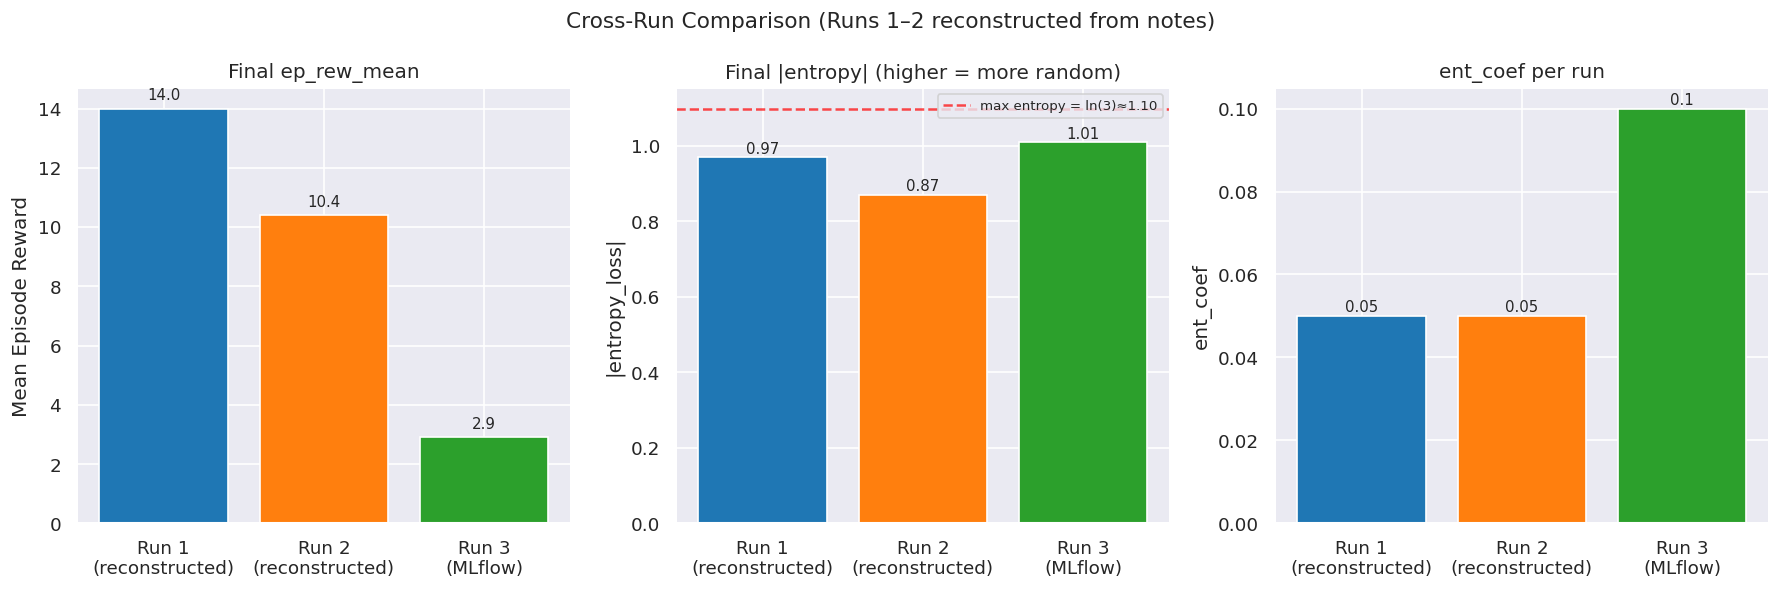


Run outcomes:
  Run 1 (reconstructed): Shaping local optimum (toward≈food reward)
  Run 2 (reconstructed): Risk-aversion local optimum (collision too costly)
  Run 3 (MLflow): ent_coef too high (policy stayed random)


In [5]:
# Reconstruct Run 1 and Run 2 from notes since MLflow data was not captured
reconstructed = pd.DataFrame([
    {
        'run': 'Run 1\n(reconstructed)',
        'food': 64.0, 'collision': -8.0, 'toward': 0.10, 'ent_coef': 0.05,
        'grid': '22×22\n(24 total)', 'max_steps': 500, 'lr': 0.0003,
        'peak_ep_rew': 30.7, 'final_ep_rew': 14.0,
        'final_ep_len': 314, 'final_entropy': -0.97,
        'stopped_at': 2_100_000,
        'outcome': 'Shaping local optimum\n(toward≈food reward)'
    },
    {
        'run': 'Run 2\n(reconstructed)',
        'food': 64.0, 'collision': -8.0, 'toward': 0.01, 'ent_coef': 0.05,
        'grid': '14×14\n(16 total, border bug)', 'max_steps': 300, 'lr': 0.0001,
        'peak_ep_rew': 10.4, 'final_ep_rew': 10.4,
        'final_ep_len': 138, 'final_entropy': -0.87,
        'stopped_at': 3_100_000,
        'outcome': 'Risk-aversion local optimum\n(collision too costly)'
    },
    {
        'run': 'Run 3\n(MLflow)',
        'food': 16.0, 'collision': -2.0, 'toward': 0.01, 'ent_coef': 0.10,
        'grid': '16×16\n(18 total)', 'max_steps': 300, 'lr': 0.0001,
        'peak_ep_rew': 4.4, 'final_ep_rew': 2.9,
        'final_ep_len': 98.5, 'final_entropy': -1.01,
        'stopped_at': 5_000_000,
        'outcome': 'ent_coef too high\n(policy stayed random)'
    },
])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Cross-Run Comparison (Runs 1–2 reconstructed from notes)', fontsize=13)

runs = reconstructed['run'].tolist()
colors = sns.color_palette('tab10', 3)

# Plot 1: final ep_rew_mean
axes[0].bar(runs, reconstructed['final_ep_rew'], color=colors)
axes[0].set_title('Final ep_rew_mean')
axes[0].set_ylabel('Mean Episode Reward')
axes[0].axhline(0, color='black', linewidth=0.5)
for i, v in enumerate(reconstructed['final_ep_rew']):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

# Plot 2: final entropy (higher magnitude = more collapsed)
axes[1].bar(runs, reconstructed['final_entropy'].abs(), color=colors)
axes[1].axhline(np.log(3), color='red', linestyle='--', alpha=0.7, label=f'max entropy = ln(3)≈1.10')
axes[1].set_title('Final |entropy| (higher = more random)')
axes[1].set_ylabel('|entropy_loss|')
axes[1].legend(fontsize=8)
for i, v in enumerate(reconstructed['final_entropy'].abs()):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

# Plot 3: ent_coef vs outcome encoding
axes[2].bar(runs, reconstructed['ent_coef'], color=colors)
axes[2].set_title('ent_coef per run')
axes[2].set_ylabel('ent_coef')
for i, v in enumerate(reconstructed['ent_coef']):
    axes[2].text(i, v + 0.001, f'{v}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/cross_run_comparison.png', bbox_inches='tight')
plt.show()

print('\nRun outcomes:')
for _, row in reconstructed.iterrows():
    print(f'  {row["run"].replace(chr(10), " ")}: {row["outcome"].replace(chr(10), " ")}')

## Entropy Goldilocks analysis

All three runs failed for opposite entropy-related reasons:

| Run | ent_coef | Final entropy | Failure mode |
|-----|----------|---------------|--------------|
| 1 | 0.05 | -0.97 (low) | Collapsed — deterministic "avoid walls" policy |
| 2 | 0.05 | -0.87 (low) | Collapsing — same deterministic local optimum forming |
| 3 | 0.10 | -1.01 (≈max) | Stuck at max — policy gradient overwhelmed by entropy bonus |

**Target zone:** entropy should stay in the range `[-0.7, -0.5]` during productive training — diverse enough to explore, committed enough to improve.

**Run 4 hypothesis:** `ent_coef=0.02` should land between collapse (0.05 was too low to prevent it) and domination (0.10 was too high). Removing `toward/away` eliminates the orbiting local optimum.

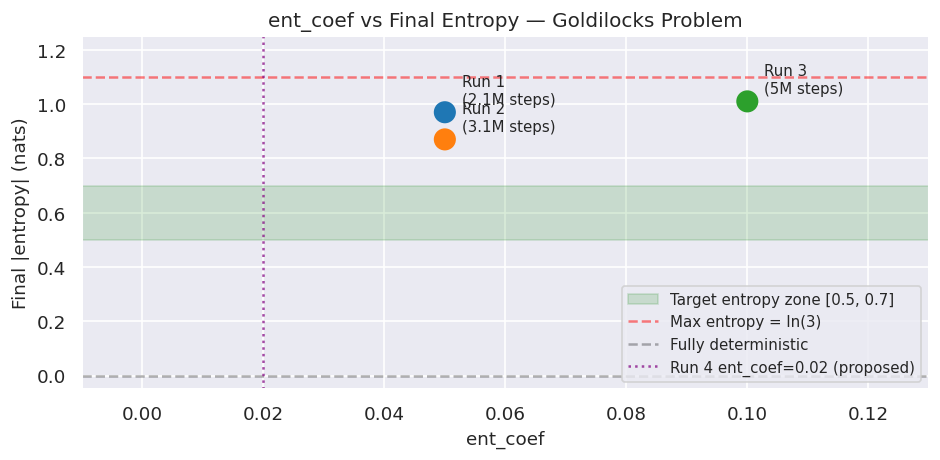

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

ent_coefs = [0.05, 0.05, 0.10]
entropies = [0.97, 0.87, 1.01]  # absolute values
labels_pts = ['Run 1\n(2.1M steps)', 'Run 2\n(3.1M steps)', 'Run 3\n(5M steps)']

ax.scatter(ent_coefs, entropies, s=150, zorder=5, color=colors)
for i, (x, y, lbl) in enumerate(zip(ent_coefs, entropies, labels_pts)):
    ax.annotate(lbl, (x, y), textcoords='offset points', xytext=(10, 5), fontsize=9)

# Target zone
ax.axhspan(0.5, 0.7, alpha=0.15, color='green', label='Target entropy zone [0.5, 0.7]')
ax.axhline(np.log(3), color='red', linestyle='--', alpha=0.5, label='Max entropy = ln(3)')
ax.axhline(0, color='black', linestyle='--', alpha=0.3, label='Fully deterministic')

# Run 4 prediction
ax.axvline(0.02, color='purple', linestyle=':', alpha=0.7, label='Run 4 ent_coef=0.02 (proposed)')

ax.set_xlabel('ent_coef', fontsize=11)
ax.set_ylabel('Final |entropy| (nats)', fontsize=11)
ax.set_title('ent_coef vs Final Entropy — Goldilocks Problem', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(-0.01, 0.13)
ax.set_ylim(-0.05, 1.25)

plt.tight_layout()
plt.savefig('../notebooks/entropy_goldilocks.png', bbox_inches='tight')
plt.show()

## Run 4 config preview

In [7]:
import yaml

with open('../config/default.yaml') as f:
    cfg = yaml.safe_load(f)

print('Current config/default.yaml:')
print(yaml.dump(cfg, default_flow_style=False))

print()
print('Proposed Run 4 changes:')
print('  ppo.ent_coef:   0.10 → 0.02')
print('  reward.toward:  0.01 → 0.0')
print('  reward.away:   -0.02 → 0.0')
print()
print('Rationale:')
print('  - ent_coef=0.02: slow entropy collapse without dominating the policy gradient')
print('  - toward=away=0: remove shaping that creates circling/orbiting local optimum')
print('  - food=16, collision=-2: already scaled well (8:1 ratio, low value-function variance)')

Current config/default.yaml:
env:
  grid_h: 16
  grid_w: 16
  max_steps: 300
mlflow:
  experiment_name: snake-rl
  tracking_uri: sqlite:///mlruns/mlflow.db
policy:
  features_dim: 64
  hidden_dims:
  - 256
  - 128
ppo:
  batch_size: 64
  clip_range: 0.2
  ent_coef: 0.1
  gae_lambda: 0.95
  gamma: 0.99
  learning_rate: 0.0001
  n_epochs: 10
  n_steps: 2048
reward:
  away: -0.02
  collision: -2.0
  food: 16.0
  toward: 0.01
training:
  model_name: snake_ppo
  n_envs: 4
  render_every_n_episodes: 24
  save_path: models/
  total_timesteps: 5000000


Proposed Run 4 changes:
  ppo.ent_coef:   0.10 → 0.02
  reward.toward:  0.01 → 0.0
  reward.away:   -0.02 → 0.0

Rationale:
  - ent_coef=0.02: slow entropy collapse without dominating the policy gradient
  - toward=away=0: remove shaping that creates circling/orbiting local optimum
  - food=16, collision=-2: already scaled well (8:1 ratio, low value-function variance)


## Helper: load any future run

Re-run this cell after starting Run 4 to add its curves to the analysis.

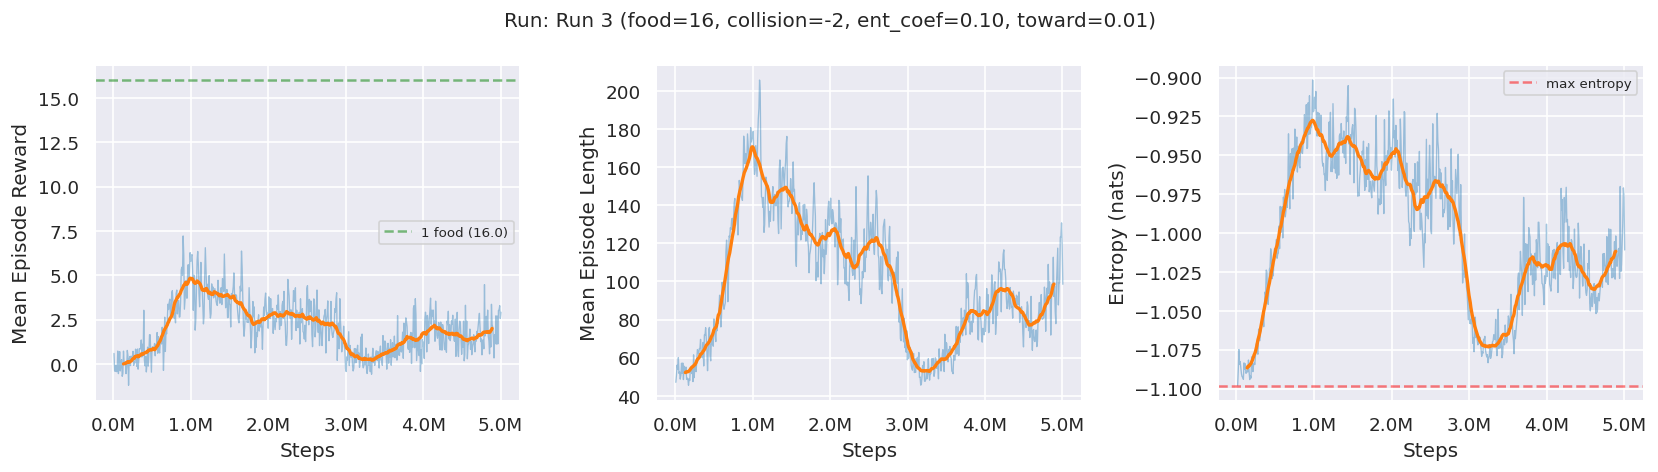

In [8]:
def plot_run_curves(run_id_prefix: str, label: str = None):
    """Plot metric curves for any run by its ID prefix."""
    all_r = client.search_runs(exp.experiment_id)
    matches = [r for r in all_r if r.info.run_id.startswith(run_id_prefix)]
    if not matches:
        print(f'No run found with prefix {run_id_prefix!r}')
        return
    run = matches[0]
    label = label or run.info.run_id[:8]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'Run: {label}', fontsize=12)

    for ax, metric, ylabel in zip(
        axes,
        ['ep_rew_mean', 'ep_len_mean', 'entropy'],
        ['Mean Episode Reward', 'Mean Episode Length', 'Entropy (nats)']
    ):
        df = get_metric_df(run.info.run_id, metric)
        if df.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue
        ax.plot(df['step'], df[metric], alpha=0.4, linewidth=0.8)
        if len(df) > 20:
            smoothed = df[metric].rolling(window=max(1, len(df)//20), center=True).mean()
            ax.plot(df['step'], smoothed, linewidth=2)
        ax.set_xlabel('Steps')
        ax.set_ylabel(ylabel)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        if metric == 'ep_rew_mean':
            food = float(run.data.params.get('reward.food', 10))
            ax.axhline(food, color='green', linestyle='--', alpha=0.5, label=f'1 food ({food})')
            ax.legend(fontsize=8)
        elif metric == 'entropy':
            ax.axhline(-np.log(3), color='red', linestyle='--', alpha=0.5, label='max entropy')
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# Example: plot_run_curves('d71a9426', label='Run 3')
plot_run_curves('d71a9426', label='Run 3 (food=16, collision=-2, ent_coef=0.10, toward=0.01)')